In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
preds = pd.read_csv('./data/predictions.csv')
train = pd.read_csv('./data/train_cleaned.csv')

In [12]:
preds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 878 entries, 0 to 877
Data columns (total 84 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     878 non-null    int64  
 1   pid                    878 non-null    int64  
 2   ms_subclass            878 non-null    int64  
 3   ms_zoning              878 non-null    object 
 4   lot_frontage           718 non-null    float64
 5   lot_area               878 non-null    int64  
 6   street                 878 non-null    object 
 7   alley                  58 non-null     object 
 8   lot_shape              878 non-null    object 
 9   land_contour           878 non-null    object 
 10  utilities              878 non-null    object 
 11  lot_config             878 non-null    object 
 12  land_slope             878 non-null    object 
 13  neighborhood           878 non-null    object 
 14  condition_1            878 non-null    object 
 15  condit

In [27]:
preds['has_garage'].unique().sum()

1

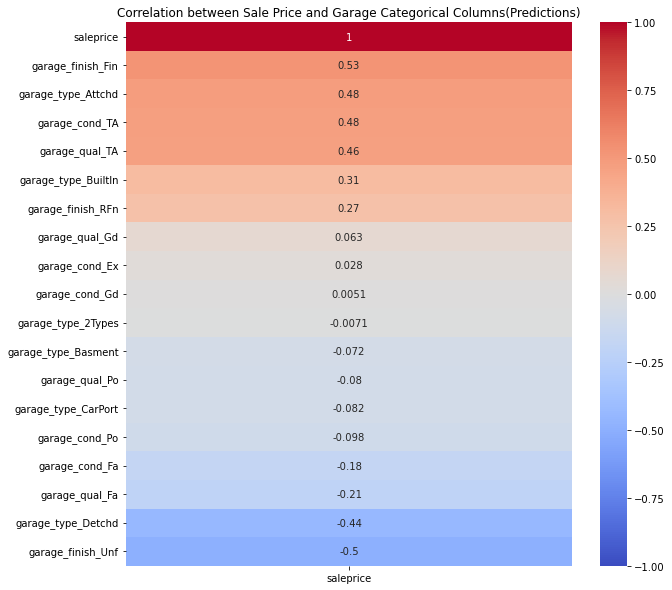

In [16]:
# Extract garage categorical columns
garage_categorical_cols = ['garage_type', 'garage_finish', 'garage_qual', 'garage_cond']

# One-hot encode the garage categorical columns
garage_encoded = pd.get_dummies(preds[garage_categorical_cols])

# Combine the one-hot encoded columns with the 'saleprice' column
combined_data = pd.concat([preds['saleprice'], 
                          garage_encoded], 
                          axis=1)

# Calculate the correlation matrix
corr_matrix = combined_data.corr()

# Sort the columns based on the correlation with 'saleprice'
sorted_corr = corr_matrix[['saleprice']].sort_values(by='saleprice', ascending=False)

# Create the heatmap
plt.figure(figsize=(10, 10)) 
sns.heatmap(sorted_corr, 
            vmin=-1, 
            cmap='coolwarm', 
            annot=True)
plt.title('Correlation between Sale Price and Garage Categorical Columns(Predictions)')
plt.show()

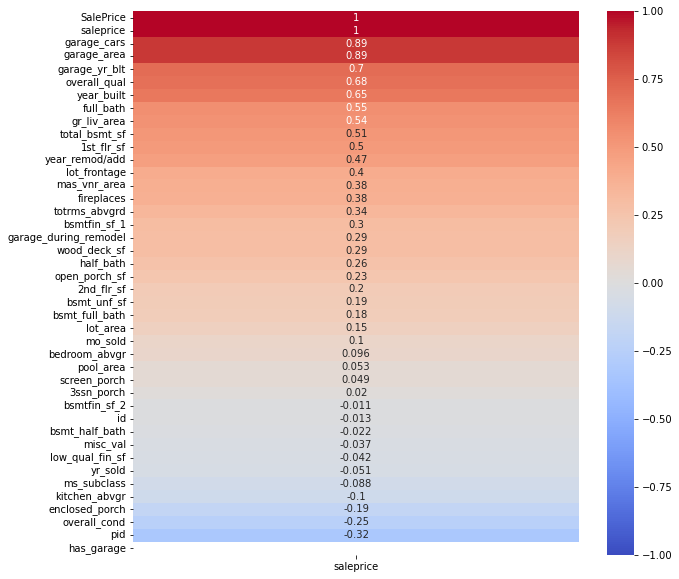

In [17]:
# heatmap of numerical cols correlation to sales price
corr = preds.corr()

plt.figure(figsize=(10, 10)) 
sns.heatmap(corr[['saleprice']].sort_values(by='saleprice', ascending=False), 
            vmin=-1,
            cmap='coolwarm',
            annot=True)
plt.show();

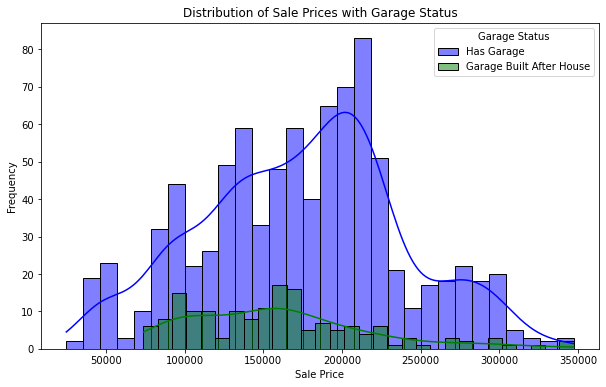

In [25]:
# Create a new DataFrame for houses with garage built after the house
houses_with_garage_after_house = preds[preds['garage_yr_blt'] > preds['year_built']]

# Create histograms to visualize the distribution between having a garage and sale price
plt.figure(figsize=(10, 6))

# Histogram for houses with a garage
sns.histplot(data=preds[preds['has_garage'] == 1], 
             x='saleprice', 
             color='blue', 
             bins=30, 
             kde=True, 
             label='Has Garage')

# Histogram for houses with a garage built after the house
sns.histplot(data=houses_with_garage_after_house, 
             x='saleprice',
             color='green', 
             bins = 30, 
             kde=True, 
             label='Garage Built After House')

# Histogram for houses without a garage
sns.histplot(data=preds[preds['has_garage'] == 0], 
             x='saleprice', 
             color='red', 
             bins= 30, 
             kde=True, 
             label='No Garage')

plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.title('Distribution of Sale Prices with Garage Status')
plt.legend(title='Garage Status')
plt.show()

In [20]:
preds['saleprice'].describe()

count       878.000000
mean     174602.309943
std       63743.765782
min       24695.301460
25%      130710.302335
50%      179106.385688
75%      215009.003841
max      347236.005093
Name: saleprice, dtype: float64

In [21]:
train['saleprice'].describe()

count      1850.000000
mean     179889.354595
std       75979.150063
min       12789.000000
25%      129900.000000
50%      162250.000000
75%      212402.250000
max      611657.000000
Name: saleprice, dtype: float64

In [11]:
# Average saleprice for houses based on garage availability
print("\nAverage saleprice for houses based on garage availability:")
print(preds.groupby('has_garage')['saleprice'].mean())

# Average saleprice for houses based on garage availability (Train)
print("\nAverage saleprice for houses based on garage availability:")
print(train.groupby('has_garage')['saleprice'].mean())


Average saleprice for houses based on garage availability:
has_garage
1    174602.309943
Name: saleprice, dtype: float64

Average saleprice for houses based on garage availability:
has_garage
0    107212.721154
1    184218.317869
Name: saleprice, dtype: float64


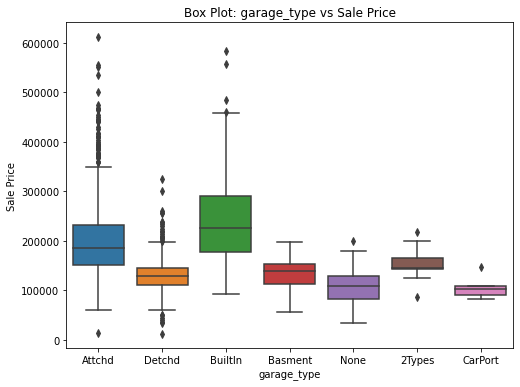

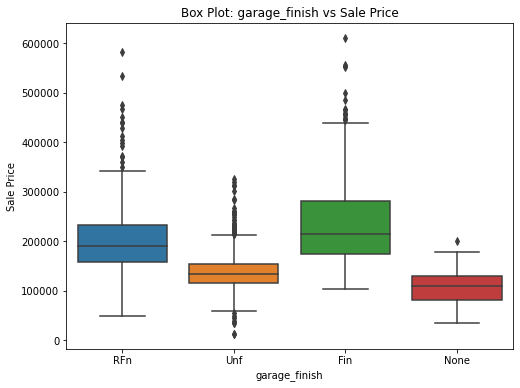

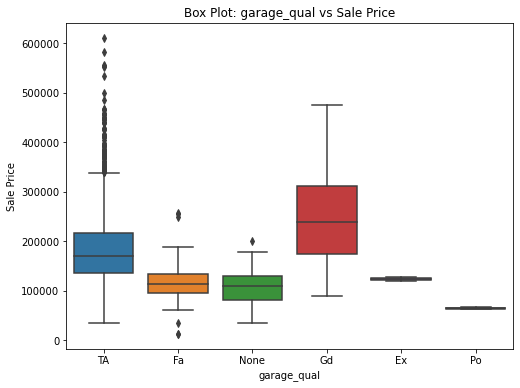

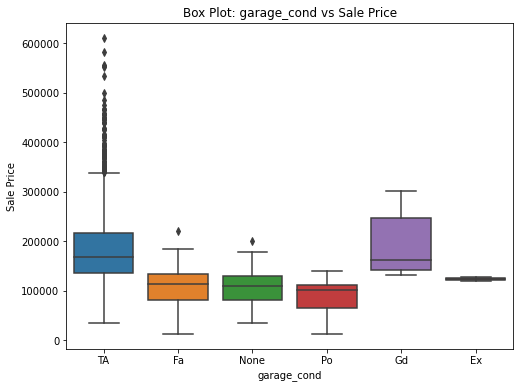

In [22]:
garage_categorical_cols = ['garage_type', 'garage_finish', 'garage_qual', 'garage_cond']

# Create individual box plots for each garage categorical column
for col in garage_categorical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=train, x=col, y='saleprice')
    plt.xlabel(col)
    plt.ylabel('Sale Price')
    plt.title(f'Box Plot: {col} vs Sale Price')
    plt.show()

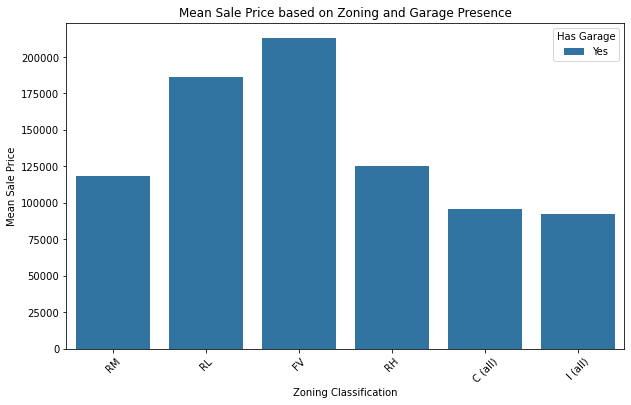

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(data=preds, x='ms_zoning', y='saleprice', hue='has_garage', errorbar=None)
plt.xlabel('Zoning Classification')
plt.ylabel('Mean Sale Price')
plt.title('Mean Sale Price based on Zoning and Garage Presence')
plt.legend(title='Has Garage', labels=['Yes', 'No'])
plt.xticks(rotation=45)
plt.show()